# House Price Prediction Using Multiple Linear Regression

## Mini Project

This project aims to predict the median house value using different
housing-related features. Multiple Linear Regression is used as the
supervised learning algorithm.

## 1. Problem Statement

House prices depend on several factors such as the number of rooms,
population, household information and location.

The objective of this project is to build a Multiple Linear Regression
model that predicts the median house value using different features
from the California Housing dataset.

This is a supervised learning regression problem because the target
variable is a continuous numerical value.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
#Load the Dataset
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
#Check Dataset Size
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20640
Number of columns: 9


In [4]:
#Check Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
#Check Missing Values
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [6]:
imputer = SimpleImputer(strategy="median")

df[df.columns] = imputer.fit_transform(df)

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [7]:
#Check Duplicate Rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
df = df.drop_duplicates()

In [9]:
#Statistical Summary
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


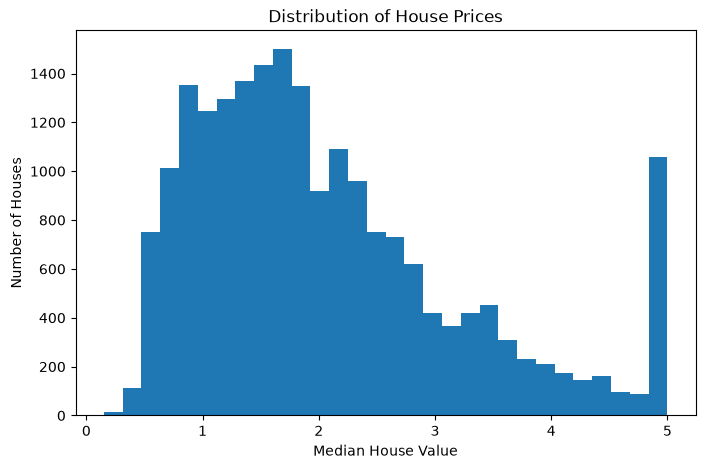

In [10]:
#Histogram of House Prices
plt.figure(figsize=(8,5))

plt.hist(df["MedHouseVal"], bins=30)

plt.xlabel("Median House Value")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")

plt.show()

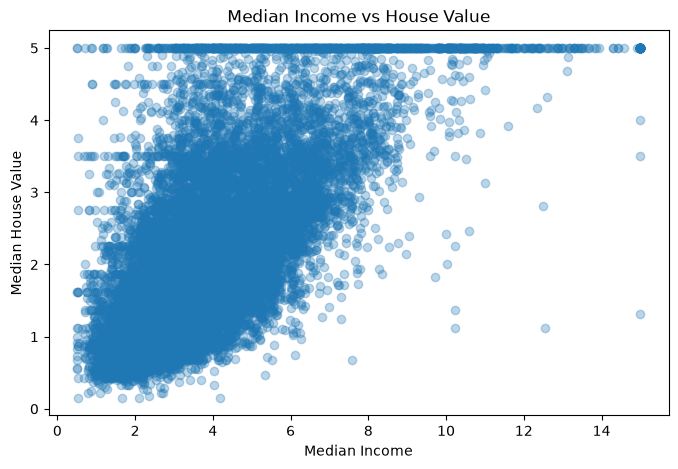

In [11]:
#Scatter Plot
plt.figure(figsize=(8,5))

plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Value")

plt.show()

In [12]:
#Correlation
correlation = df.corr()

print(correlation["MedHouseVal"].sort_values(ascending=False))

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [13]:
#Select Features and Target
X = df[["MedInc", "HouseAge", "AveRooms", "AveOccup"]]

y = df["MedHouseVal"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   MedInc  HouseAge  AveRooms  AveOccup
0  8.3252      41.0  6.984127  2.555556
1  8.3014      21.0  6.238137  2.109842
2  7.2574      52.0  8.288136  2.802260
3  5.6431      52.0  5.817352  2.547945
4  3.8462      52.0  6.281853  2.181467

Target:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [14]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (14448, 4)
Testing data: (6192, 4)


In [15]:
#Build Multiple Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [16]:
#Make Predictions
y_pred = model.predict(X_test)

print("First 10 predicted values:")
print(y_pred[:10])

First 10 predicted values:
[1.06580636 1.50964133 2.3343204  2.6772473  2.09484413 2.1656919
 2.70932797 2.15595595 2.10805857 4.18668613]


In [17]:
#Model Evaluation
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R² Score: 0.5137729946154257
RMSE: 0.7988694799962514
MAE: 0.5960201675946688


In [18]:
#Print Coefficients
print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: 0.02199525523164958

Coefficients:
MedInc : 0.4427025660685973
HouseAge : 0.016912455309449997
AveRooms : -0.025743735278315392
AveOccup : -0.003958524480189229


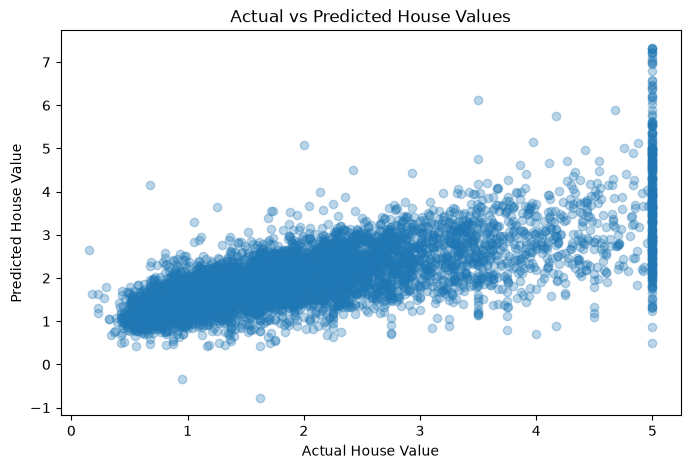

In [19]:
#Actual vs Predicted Graph
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [20]:
#Adjusted R²
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("R² Score:", r2)
print("Adjusted R²:", adjusted_r2)

R² Score: 0.5137729946154257
Adjusted R²: 0.5134586406439471


In [21]:
#Final Results Table
results = pd.DataFrame({
    "Metric": ["R²", "Adjusted R²", "RMSE", "MAE"],
    "Value": [r2, adjusted_r2, rmse, mae]
})

results

,Metric,Value
0,R²,0.513773
1,Adjusted R²,0.513459
2,RMSE,0.798869
3,MAE,0.596020


## 7. Conclusion

In this project, a Multiple Linear Regression model was developed to
predict median house values using housing-related features from the
California Housing dataset.

The data was explored using descriptive statistics and visualizations.
The dataset was divided into training and testing sets, with 70% used
for training and 30% used for testing.

The model was evaluated using R², Adjusted R², RMSE and MAE.

The results show how multiple housing features can be used to predict
house values. The coefficient values also help us understand the
relationship between the input variables and the predicted house value.

### Limitations

1. The model uses only a selected number of features.
2. Linear Regression assumes a linear relationship between predictors
   and the target.
3. Real-world house prices can be affected by many other factors.
4. The model may not perform equally well for every geographical area.

### Future Improvement

Other machine learning algorithms such as Random Forest or Gradient
Boosting could be tested and compared with Linear Regression.